In [1]:
import pandas as pd
import os
import numpy as np
import subprocess

from Bio import SearchIO
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq
from Bio import SeqIO, AlignIO
from Bio import Align
from collections import defaultdict
import itertools
import pyranges as pr

import RNA

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import precision_recall_curve, auc, roc_auc_score, top_k_accuracy_score, roc_curve
from pathlib import Path
import matplotlib.patches as mpatches

In [ ]:
data_path = 'data'

# Functions

In [3]:
def bpseq2mat(bpseq):

    """
    From Xavi's code
    """
    
    ci_matrix = np.zeros((max(bpseq[0]),max(bpseq[0])))
    ci_matrix[bpseq[0][bpseq[1]>0]-1,
              bpseq[1][bpseq[1]>0]-1] = 1
    return ci_matrix
    
def get_comparna_gt(pdb_id):

    gt_comparna_folder = data_path
    
    path_wccis = os.path.join(gt_comparna_folder, "comparna_pdb_WCcis", pdb_id+".bpseq" )
    path_ext = os.path.join(gt_comparna_folder,"comparna_pdb_ext", pdb_id+"_ext.bpseq")
    seq, bpseq = open_bpseq(path_wccis)
    WCmatrix = bpseq2mat(bpseq)
    seq, bpseq = open_bpseq(path_ext)
    truematrix = bpseq2mat(bpseq)
    allmatrix = WCmatrix - (truematrix - WCmatrix)
    extmatrix = truematrix - WCmatrix

    return allmatrix, WCmatrix, extmatrix


def open_bpseq(bpseq_file):
    
    seq = ""
    bpseq_idx = []
    bpseq_ct = []
    lastidx = "0"
    with open(bpseq_file) as f:
        for line in f:
            splitted = line.rstrip().split(" ")
            if splitted[0]!=lastidx:
                seq += splitted[1]
                lastidx = splitted[0]
            bpseq_idx.append(splitted[0])
            bpseq_ct.append(splitted[2])
    bpseq = [np.array(bpseq_idx, dtype=int),np.array(bpseq_ct, dtype=int)]
    return seq, bpseq


def get_predicted_matrix(pred_matrix, noncontact_mask, x_get, y_get):

    contact_values = pred_matrix[x_get, y_get]
    noncontact_values = pred_matrix[noncontact_mask]

    pred_values = np.concatenate((noncontact_values, contact_values), axis=0)
    return pred_values

def parse_alifold_output(file_aliout):

    all_rows = []
    with open(file_aliout,"r") as f:
    
        # Last row contains dot bracket notation
        lines = f.readlines()[2:]
    
        dbnotation = lines[-1].strip()
        len_seq = len(dbnotation)
        
        for line in lines[:-1]:
            items = line.split()
            i, j, _, p_ij = items[:4]
            all_rows.append((int(i)-1, int(j)-1, float(p_ij[:-1])))
    
    df = pd.DataFrame(all_rows, columns=['pos_i', 'pos_j', 'p_ij'])

    # Extract row and column information
    rowIDs = df['pos_i']
    colIDs = df['pos_j']
    
    mat = np.zeros((len_seq, len_seq))
    mat[rowIDs,colIDs] = df['p_ij']

    return mat, dbnotation


def get_rnaalifold_reduced_matrix_fasta(file_final_aliout, fasta_alignment, orig_seq, method=None):

    mat1, dbnotation = parse_alifold_output(file_final_aliout)
    
    # Subset matrix to positions with sequence
    pdb_entry = list(AlignIO.parse(fasta_alignment, "fasta"))[0]

    # Deal with the different outputs from alignment
    if method == "mafft":
        orig_seq = orig_seq.replace("U","T").lower()
    elif method in ["clustalo","muscle"]:
        orig_seq = orig_seq.replace("U","T")
    
    mat2, clean_seq = None, None
    for entry in pdb_entry:
        
        aligned_seq = entry.seq
        clean_seq, _ = clean_aligned_seq(str(aligned_seq))

        if clean_seq == orig_seq:
            
            assert len(aligned_seq) == mat1.shape[0]
            target_idxs = get_informative_indices_rnaalifold(aligned_seq, sep="-", dms_filter=False)
            remove_idxs = list(set(list(range(len(aligned_seq)))).difference(set(target_idxs)))
            mat2 = reduce(mat1, remove_idxs)
            mat2 = mat2 + mat2.T

            break

    return mat2, clean_seq


def get_informative_indices_rnaalifold(aligned_seq, sep="-", dms_filter=False):
    
    # Get indices where there is a base
    if dms_filter:
        seq_indices = [i for i, elem in enumerate(aligned_seq) if elem != sep and elem in ["A","C"]]
    else:
        seq_indices = [i for i, elem in enumerate(aligned_seq) if elem != sep]
    return seq_indices

    
def clean_aligned_seq(aligned_seq, sep="-", dbnot=None, dms_filter=False):
    
    # Get indices where there is a base
    seq_indices = get_informative_indices_rnaalifold(aligned_seq, sep=sep, dms_filter=dms_filter)

    clean_dbnot = None
    clean_seq = ''.join([aligned_seq[i] for i in seq_indices])
    if dbnot:
        clean_dbnot = ''.join([dbnot[i] for i in seq_indices])
        
    return clean_seq, clean_dbnot


def reduce(matrix, idx_to_del):

    matrix = np.delete(matrix, idx_to_del, axis=0)
    matrix = np.delete(matrix, idx_to_del, axis=1)

    return matrix

# Plotting

In [4]:
def plot_pr_curves_wc_noncanon(list_of_result_dicts, nrows=2, ncols=2):

    # Panel 1: WCcis Default
    # Panel 2: Non-canonical Default 
    # Panel 3: WCcis RIBOSUM
    # Panel 4: Non-canonical RIBOSUM
    
    names_dicts = ["WCcis - Default energy model","Non-canonical - Default energy model",
                   "WCcis - RIBOSUM scoring","Non-canonical - RIBOSUM scoring"]

    methods = ["rinalmo","mafft", "clustalo", "finetuned"]
    labels = ["Dependency", "RNAlifold MAFFT", "RNAlifold ClustalO", 'Fine-tuned RiNALMo']
    colors = ["royalblue","darkorange","darkgreen","lightblue", "darkviolet"]
    
    plt.figure(figsize=(12,12))
    
    for ii, dict_results in enumerate(list_of_result_dicts):
        
        gt_values = np.hstack(dict_results["ground_truth"])
        
        dict_per_method = {k:[] for k in methods}
        for method in methods:
            pred_values = np.hstack(dict_results[method])
            precision,recall,_ = precision_recall_curve(gt_values, pred_values)
            auprc = auc(recall, precision)
            dict_per_method[method] = [recall, precision, auprc]
    
        plt.subplot(nrows, ncols, (ii+1), box_aspect=1)
        for idx, method in enumerate(methods):
            recall, precision, auprc = dict_per_method[method]
            auprc = "%.3f" % round(auprc, 3)
            plt.plot(recall, precision, label= f"{labels[idx]} (AUC= {auprc})", c=colors[idx])
        plt.title(names_dicts[ii],fontsize=14)
        plt.xlabel("Recall", fontsize=14)
        plt.ylabel("Precision", fontsize=14)
        plt.tight_layout()
        plt.legend(loc='best', fontsize=14)
    
    plt.show()
    
def plot_roc_curves_wc_noncanon(list_of_result_dicts, nrows=2, ncols=2):

    # Panel 1: WCcis Default
    # Panel 2: Non-canonical Default 
    # Panel 3: WCcis RIBOSUM
    # Panel 4: Non-canonical RIBOSUM
    
    names_dicts = ["WCcis - Default energy model","Non-canonical - Default energy model",
                   "WCcis - RIBOSUM scoring","Non-canonical - RIBOSUM scoring"]

    methods_per_plot = ["rinalmo","mafft", "clustalo", "finetuned"]
    labels_per_plot = ["Dependency", "RNAlifold MAFFT", "RNAlifold ClustalO", 'Fine-tuned RiNALMo']
    colors_per_plot = ["royalblue","darkorange","darkgreen","lightblue", "darkviolet"]

    plt.figure(figsize=(12,12))
    
    for ii, dict_results in enumerate(list_of_result_dicts):
        
        gt_values = np.hstack(dict_results["ground_truth"])
        
        dict_per_method = {k:[] for k in methods_per_plot}
        for method in methods_per_plot:
            pred_values = np.hstack(dict_results[method])
            fpr,tpr,_ = roc_curve(gt_values, pred_values)
            auroc = auc(fpr, tpr)
            dict_per_method[method] = [fpr, tpr, auroc]
    
        plt.subplot(nrows, ncols, (ii+1), box_aspect=1)
        for idx, method in enumerate(methods_per_plot):
            fpr, tpr, auroc = dict_per_method[method]
            auroc = "%.3f" % round(auroc, 3)
            plt.plot(fpr, tpr, label= f"{labels_per_plot[idx]} (AUC= {auroc})", c=colors_per_plot[idx])
        plt.title(names_dicts[ii],fontsize=14)
        plt.xlabel("FPR", fontsize=14)
        plt.ylabel("TPR", fontsize=14)
        plt.tight_layout()
        plt.legend(loc='lower right', fontsize=14)
    
    plt.show()

In [5]:
# All CompaRNA PDB IDs with NHMMER fasta
input_dir_fastas = os.path.join(data_path, "PIPELINE2/01_NHMMER_fastas")
all_pdbs_with_nhmmer_hits = [os.path.basename(file).split(".")[0] for file in os.listdir(input_dir_fastas)]
print("No. of CompaRNA PDB IDs with hits in Danny's database: ", len(all_pdbs_with_nhmmer_hits))

No. of CompaRNA PDB IDs with hits in Danny's database:  88


In [6]:
# --------Get pdb ids that have Rfam mappings--------

file_rfam = os.path.join(data_path, "01_rfam_seed_aln_rnaalifold/Rfam_data/Rfam.pdb")
df = pd.read_csv(file_rfam, sep="\t")
df["pdb_id_chain"] = df["pdb_id"] + "_" + df["chain"]

ext_dir = os.path.join(data_path, "comparna_pdb_ext")
dict_comparna_pdb_seqs = {}
for f in os.listdir(ext_dir):
    if f.endswith(".bpseq"):
        file = os.path.join(ext_dir, f)
        seq, bps = open_bpseq(file)
        dict_comparna_pdb_seqs[f] = seq
dict_comparna_pdb_seqs = {k.split("_ext")[0]:v for k,v in dict_comparna_pdb_seqs.items()}

df_rfam_comparna = df[df.pdb_id_chain.str.upper().isin(list(dict_comparna_pdb_seqs.keys()))]
print(df_rfam_comparna.shape)

all_pdb_ids_in_rfam = list(set([entry.upper() for entry in list(set(df_rfam_comparna.pdb_id_chain))]))
print(len(all_pdb_ids_in_rfam))

(72, 11)
60


In [7]:
all_pdbs_pipeline1 = ['2LC8_A',
 '2MF0_G',
 '2WW9_D',
 '3J0L_7',
 '3NDB_M',
 '4ATO_G',
 '4C4Q_N',
 '4ENB_A',
 '2KE6_A',
 '2KUR_A',
 '2KUU_A',
 '2KUV_A',
 '2KUW_A',
 '2L3J_B',
 '2L94_A',
 '2MIY_A',
 '2XXA_G',
 '3ADB_C',
 '3G4S_9',
 '3GX2_A',
 '3HJW_D',
 '3IYQ_A',
 '3J16_L',
 '3J3V_B',
 '3PDR_A',
 '3SN2_B',
 '4AOB_A',
 '4ENC_A',
 '4FRG_B',
 '4FRN_A',
 '4P8Z_A',
 '4PQV_A',
 '5CCB_N']

In [8]:
remove_long_seqs = []
for pdb_chain in all_pdbs_with_nhmmer_hits:
    # Get original sequence
    file_bpseq_all = os.path.join(data_path, f"CompaRNA_PDB/{pdb_chain}.bpseq")
    orig_seq, bpseq = open_bpseq(file_bpseq_all)  
    if len(orig_seq) > 1024:
        remove_long_seqs.append(pdb_chain)
remove_long_seqs = list(set(remove_long_seqs))
print(len(remove_long_seqs))

5


In [9]:
all_pdbs_pipeline2 = set(set(all_pdbs_with_nhmmer_hits).difference(set(all_pdbs_pipeline1)))
len(all_pdbs_pipeline2)

all_pdbs_pipeline2 = list(set(all_pdbs_pipeline2).difference(set(remove_long_seqs)))
len(all_pdbs_pipeline2)

67

# Main

In [10]:
main_dir = os.path.join(data_path, "PIPELINE2")

# ---------------------Dependency map outputs---------------------
rinalmo_dir = os.path.join(main_dir, "02_RiNALMo_outputs")

# ---------------------Use this if we use the top 1000 NHMMER hits for big alignments---------------------
# # Alignments
# mafft_dir = os.path.join(main_dir, "03_RNAalifold_outputs_MAFFT_TOP1000_FINAL")
# clustalo_dir = os.path.join(main_dir, "03_RNAalifold_outputs_CLUSTALO_TOP1000_FINAL")

# # RNAalifold outputs
# clustalo_alns = os.path.join(main_dir, "02_CLUSTALO_alignments_FINAL_TOP1000")
# mafft_alns = os.path.join(main_dir, "02_MAFFT_alignments_FINAL_TOP1000")

# ---------------------Use this if we use the subsampled 1000 NHMMER hits for big alignments---------------------
# Alignments
clustalo_alns = os.path.join(main_dir, "02_CLUSTALO_alignments_FINAL")
mafft_alns = os.path.join(main_dir, "02_MAFFT_alignments_FINAL")

# RNAalifold outputs
mafft_dir = os.path.join(main_dir, "03_RNAalifold_outputs_MAFFT_Random1000_FINAL")
clustalo_dir = os.path.join(main_dir, "03_RNAalifold_outputs_CLUSTALO_Random1000_FINAL")

# ---------------------Assign folders---------------------
dict_output_dirs = {"mafft": mafft_dir,
                   "clustalo": clustalo_dir}

dict_folders_aln = {"mafft": mafft_alns,
                   "clustalo": clustalo_alns}

In [11]:
alifold_modes = ["default","ribosum"]
contact_types = ["wc", "ext"]
all_methods = ["ground_truth", "rinalmo","clustalo","mafft", "finetuned"]

dict_results = defaultdict(lambda: defaultdict(int))
for mode in alifold_modes:
    dict_results[mode] = {}
    for contact in contact_types:
        dict_results[mode][contact] = {}
        for method in all_methods:
            dict_results[mode][contact][method] = []

all_eval_modes = itertools.product(alifold_modes, all_pdbs_pipeline2)

for alifold_mode, pdb_chain in all_eval_modes:

    # ---------------------Get ground truth---------------------
    # Get original sequence
    file_bpseq_all = os.path.join(data_path, f"CompaRNA_PDB/{pdb_chain}.bpseq")
    orig_seq, bpseq = open_bpseq(file_bpseq_all)  
    # Get ground truth structure from CompaRNA
    allmatrix, WCmatrix, extmatrix = get_comparna_gt(pdb_chain)
    # Get the coordinates of all GT contacts (WC + ext)
    x_ext, y_ext = np.where(allmatrix == -1)
    x_wc, y_wc = np.where(allmatrix == 1)
    # Get GT noncontact values
    noncontact_mask = np.tri(allmatrix.shape[0], k=-1, dtype=bool).T
    # Remove WCcis and ext contacts from the noncontact mask
    noncontact_mask[x_ext, y_ext] = False
    noncontact_mask[x_wc, y_wc] = False
    gt_noncontact = WCmatrix[noncontact_mask]
    # Get GT contact values
    len_targ_wc = int(len(x_wc) / 2)
    len_targ_ext = int(len(x_ext) / 2)
    x_wc, y_wc = x_wc[:len_targ_wc], y_wc[:len_targ_wc]
    x_ext, y_ext = x_ext[:len_targ_ext], y_ext[:len_targ_ext]
    gt_contact_wc = WCmatrix[x_wc, y_wc]
    gt_contact_ext = extmatrix[x_ext, y_ext]
    
    # ---------------------Get RiNALMo results---------------------
    file_rinalmo_mat = os.path.join(rinalmo_dir, f"rinalmo_{pdb_chain}.npy")
    ci_matrix = np.load(file_rinalmo_mat)

    # ---------------------Get Fine-tuned Rinalmo results---------------------
    probpath = os.path.join(os.path.join(data_path, 'comparna_pdb_WCcis/probs/',pdb_chain+"_probs.npy"))
    finetuned_preds = np.load(probpath)

    # ---------------------Record info for Ground truth---------------------
    dict_results[alifold_mode]["wc"]["ground_truth"].append(np.concatenate((gt_noncontact, gt_contact_wc)))
    dict_results[alifold_mode]["ext"]["ground_truth"].append(np.concatenate((gt_noncontact, gt_contact_ext)))

    # ---------------------Record info for Dependency maps---------------------
    dict_results[alifold_mode]["wc"]["rinalmo"].append(get_predicted_matrix(ci_matrix, noncontact_mask, x_wc, y_wc))
    dict_results[alifold_mode]["ext"]["rinalmo"].append(get_predicted_matrix(ci_matrix, noncontact_mask, x_ext, y_ext))    

    # ---------------------Record info for Fine-tuned Rinalmo---------------------
    dict_results[alifold_mode]["wc"]["finetuned"].append(get_predicted_matrix(finetuned_preds, noncontact_mask, x_wc, y_wc))
    dict_results[alifold_mode]["ext"]["finetuned"].append(get_predicted_matrix(finetuned_preds, noncontact_mask, x_ext, y_ext))



    # ---------------------Get and record results for RNAalifold on different alignments---------------------
    for method in ["mafft", "clustalo"]:
        
        fasta_alignment = os.path.join(dict_folders_aln[method], f"{pdb_chain}_aligned.fa")                
        file_alifold = os.path.join(dict_output_dirs[method], f"rnaalifold_{pdb_chain}_{alifold_mode}_ALIOUT.out")
        
        pred_mat, dbnotation = get_rnaalifold_reduced_matrix_fasta(file_alifold, fasta_alignment, orig_seq, method=method)
        dict_results[alifold_mode]["wc"][method].append(get_predicted_matrix(pred_mat, noncontact_mask, x_wc, y_wc))
        dict_results[alifold_mode]["ext"][method].append(get_predicted_matrix(pred_mat, noncontact_mask, x_ext, y_ext))

In [12]:
# Sanity check
alifold_mode = "default"

print(len(dict_results[alifold_mode]["wc"]["ground_truth"]))
print(len(dict_results[alifold_mode]["wc"]["rinalmo"]))
print(len(dict_results[alifold_mode]["wc"]["finetuned"]))
print(len(dict_results[alifold_mode]["wc"]["mafft"]))
print(len(dict_results[alifold_mode]["wc"]["clustalo"]))

print(len(dict_results[alifold_mode]["ext"]["ground_truth"]))
print(len(dict_results[alifold_mode]["ext"]["rinalmo"]))
print(len(dict_results[alifold_mode]["ext"]["finetuned"]))
print(len(dict_results[alifold_mode]["ext"]["mafft"]))
print(len(dict_results[alifold_mode]["ext"]["clustalo"]))

67
67
67
67
67
67
67
67
67
67


### Using the top 1000 hits from the NHMMER search to build the ClustalO and MAFFT alignments

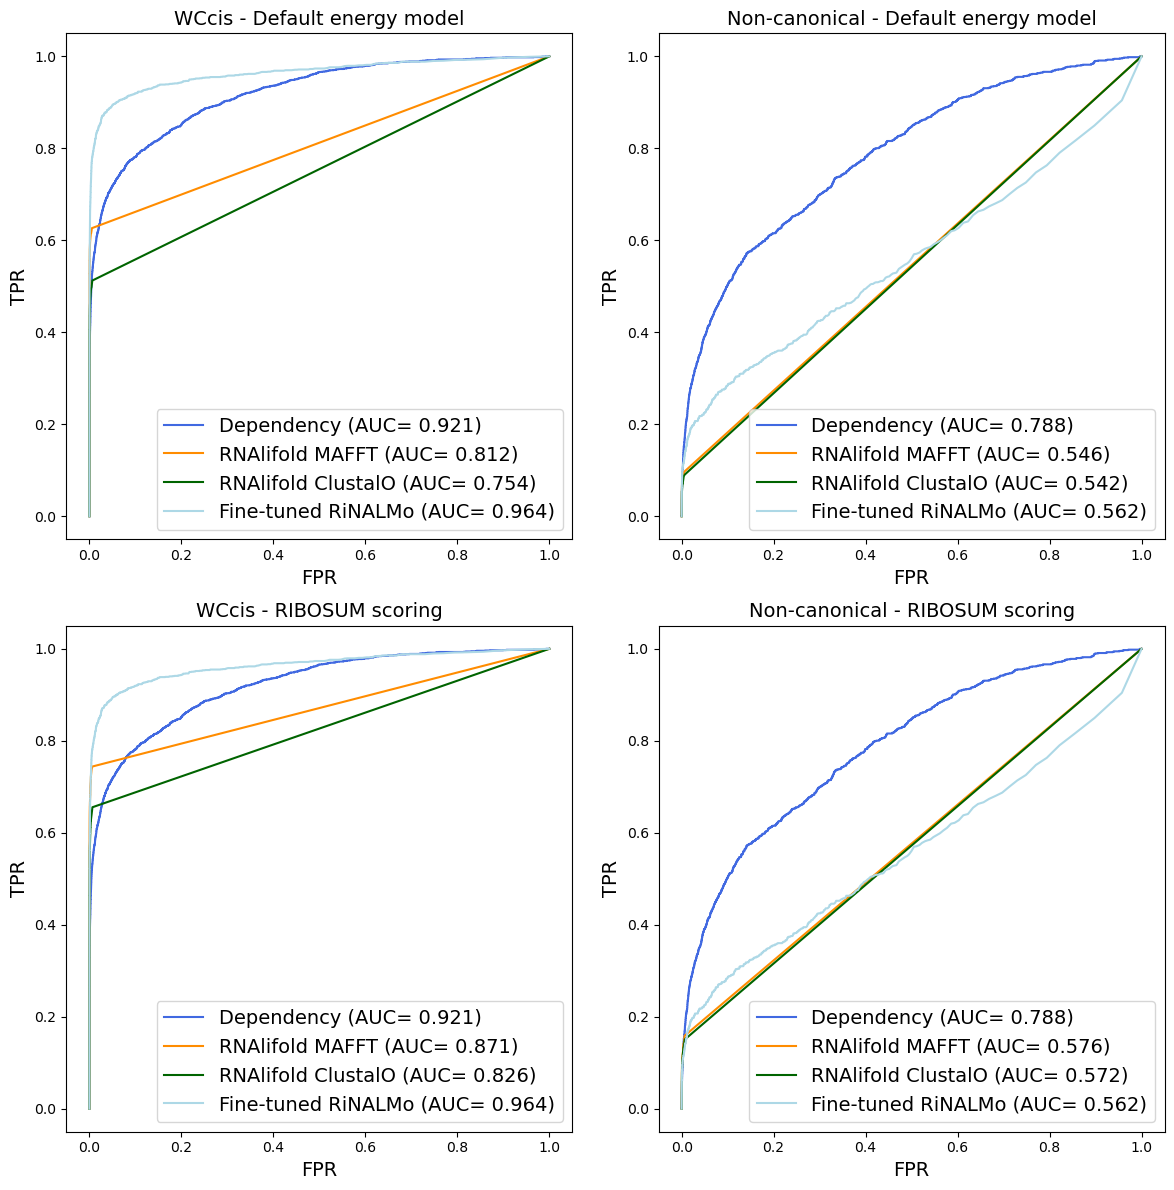

In [13]:
# Plot the ROC curves
list_of_result_dicts = [dict_results["default"]["wc"], dict_results["default"]["ext"], dict_results["ribosum"]["wc"], dict_results["ribosum"]["ext"]]
plot_roc_curves_wc_noncanon(list_of_result_dicts)